# 📊 NSL-KDD QSVM — EDA & PCA Baseline Analysis

**Notebook:** `01_EDA_and_PCA_Baseline.ipynb`  
**Project:** Quantum SVM for Network Intrusion Detection (NIDS)  
**Dataset:** NSL-KDD (binary classification: Normal vs. Attack)

---

## Overview

This notebook documents the baseline Exploratory Data Analysis (EDA) and dimensionality reduction metrics produced during **Phase 1 (Data Preprocessing)** of the QSVM pipeline. It answers three foundational questions:

1. **Class Balance** — How evenly distributed are the Normal and Attack classes? Does class imbalance risk biasing the SVM?
2. **PCA Efficiency** — How much information (variance) is retained when compressing 20 features down to 4 principal components (the hard qubit limit)?
3. **Linear Separability** — Are the two classes visually separable in the PCA-reduced 4-D space? This predicts whether a kernel-based classifier will struggle or succeed.

### Pipeline Context

```
Raw NSL-KDD (41 features)
     │
     ├─ Drop difficulty_level
     ├─ Binary label encoding (normal=0, attack=1)
     ├─ One-Hot Encoding of 3 categorical columns  →  122 features
     ├─ SelectKBest(f_classif, k=20)               →   20 features
     ├─ PCA(n_components=4)                         →    4 features   ← visualised here
     └─ MinMaxScaler(feature_range=(0, π))          →  values ∈ [0, π]  (quantum angles)
```

The final 4-D scaled arrays (`X_train.npy`, `X_test.npy`) loaded here are the direct input to the Quantum SVM kernel in Phase 2.

## 0 · Imports & Global Style

All visualization code uses **Matplotlib** and **Seaborn** with the `"whitegrid"` academic theme.  
Figures are saved to `reports/` at **300 DPI** for publication-quality output.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3d projection

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT         = Path("..").resolve()
PROCESSED    = ROOT / "data" / "processed"
MODELS       = ROOT / "models"
REPORTS      = ROOT / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

# ── Global style ───────────────────────────────────────────────────────────
# "whitegrid" gives a clean academic look: white background + subtle grey
# horizontal grid lines that aid numeric reading without visual clutter.
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.15)

# Use a consistent colour palette throughout the notebook.
# Class 0 (Normal traffic) → steel-blue;  Class 1 (Attack) → crimson-red.
CLASS_COLORS = {0: "#3B82C4", 1: "#E05252"}
CLASS_LABELS = {0: "Normal (0)", 1: "Attack (1)"}

FIGURE_DPI   = 300
SCATTER_ALPHA = 0.35   # transparency for scatter points (large N → overplot)
SUBSAMPLE_N  = 6_000   # max points in scatter plots (stratified for speed)

print("Environment ready.")
print(f"Reports directory: {REPORTS}")

Environment ready.
Reports directory: D:\QSVM_NSLKDD\reports


## 1 · Data Loading

We load the **final preprocessed arrays** produced by `src/data_preprocessing.py`.

| Array | Shape | Description |
|---|---|---|
| `X_train.npy` | (125 973, 4) | 4 PCA components, scaled to `[0, π]` |
| `y_train.npy` | (125 973,) | Binary labels: `0` = Normal, `1` = Attack |

> **Why `[0, π]`?**  
> Each feature value is used as a rotation angle in a quantum RY gate:  
> `RY(θ)|0⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩`.  
> Scaling to `[0, π]` maps the full Bloch-sphere hemisphere, maximising the  
> expressibility of the ZZFeatureMap quantum circuit.

In [2]:
X_train = np.load(PROCESSED / "X_train.npy").astype(np.float32)
y_train = np.load(PROCESSED / "y_train.npy")

n_samples, n_features = X_train.shape
n_normal = int((y_train == 0).sum())
n_attack = int((y_train == 1).sum())

print(f"X_train shape : {X_train.shape}  |  dtype: {X_train.dtype}")
print(f"y_train shape : {y_train.shape}  |  dtype: {y_train.dtype}")
print(f"Feature range : [{X_train.min():.4f}, {X_train.max():.4f}]  rad")
print()
print(f"Class 0 (Normal) : {n_normal:>7,}  ({100*n_normal/n_samples:.2f}%)")
print(f"Class 1 (Attack) : {n_attack:>7,}  ({100*n_attack/n_samples:.2f}%)")
print(f"Total            : {n_samples:>7,}")
print()
print("PCA component statistics:")
for i in range(n_features):
    print(f"  PC{i+1}: mean={X_train[:,i].mean():.4f}  "
          f"std={X_train[:,i].std():.4f}  "
          f"min={X_train[:,i].min():.4f}  "
          f"max={X_train[:,i].max():.4f}")

X_train shape : (125973, 4)  |  dtype: float32
y_train shape : (125973,)  |  dtype: int64
Feature range : [0.0000, 3.1416]  rad

Class 0 (Normal) :  67,343  (53.46%)
Class 1 (Attack) :  58,630  (46.54%)
Total            : 125,973

PCA component statistics:
  PC1: mean=1.1447  std=0.7510  min=0.0000  max=3.1416
  PC2: mean=1.2494  std=0.5558  min=0.0000  max=3.1416
  PC3: mean=2.3552  std=0.5016  min=0.0000  max=3.1416
  PC4: mean=1.6972  std=0.6069  min=0.0000  max=3.1416


## 2 · Class Distribution

### Why class imbalance matters for SVMs

A standard SVM minimises the total number of margin violations.  If 90% of training samples are class A, it is "cheaper" for the SVM to classify everything as A — the model ignores class B entirely.

The NSL-KDD training set has a **mild imbalance**: ~53.5% Normal vs ~46.5% Attack.  
This is manageable, but we use `class_weight='balanced'` in all SVC instances to compensate.

The pie chart below shows the exact proportions.  The bar chart shows raw counts and makes it easier to read absolute numbers.

Saved → D:\QSVM_NSLKDD\reports\class_distribution.png


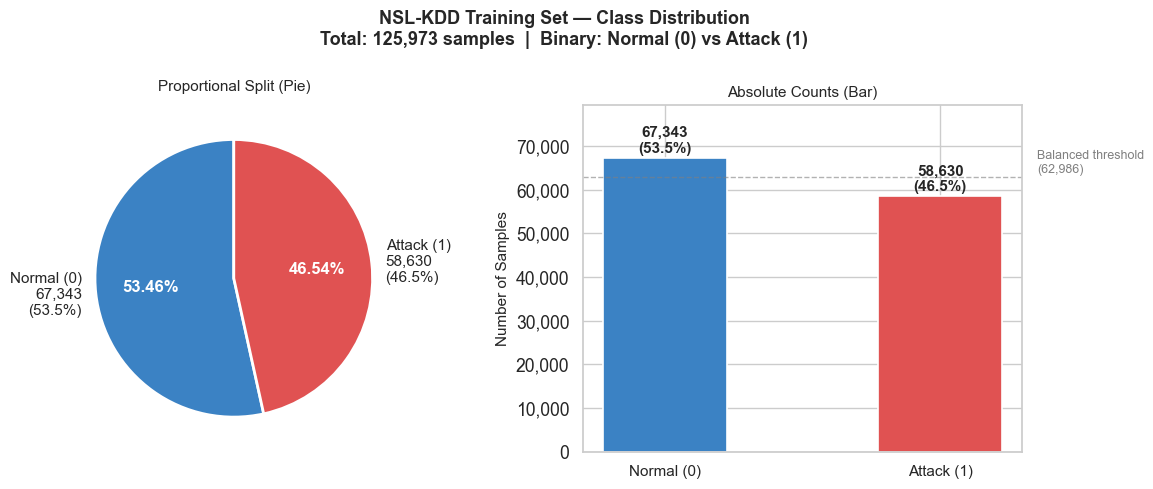

In [3]:
fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "NSL-KDD Training Set — Class Distribution\n"
    f"Total: {n_samples:,} samples  |  Binary: Normal (0) vs Attack (1)",
    fontsize=13, fontweight="bold",
)

counts = [n_normal, n_attack]
colors = [CLASS_COLORS[0], CLASS_COLORS[1]]
labels = [f"Normal (0)\n{n_normal:,}\n({100*n_normal/n_samples:.1f}%)",
          f"Attack (1)\n{n_attack:,}\n({100*n_attack/n_samples:.1f}%)"]

# ── Pie chart ──────────────────────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.6,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
    at.set_fontsize(12)
ax_pie.set_title("Proportional Split (Pie)", fontsize=11, pad=10)

# ── Bar chart ──────────────────────────────────────────────────────────────
bars = ax_bar.bar(
    [CLASS_LABELS[0], CLASS_LABELS[1]],
    counts,
    color=colors,
    width=0.45,
    edgecolor="white",
    linewidth=1.2,
)
# Annotate bars with exact counts and percentages.
for bar, count in zip(bars, counts):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f"{count:,}\n({100*count/n_samples:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax_bar.set_ylabel("Number of Samples", fontsize=11)
ax_bar.set_title("Absolute Counts (Bar)", fontsize=11)
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_bar.set_ylim(0, max(counts) * 1.18)
ax_bar.tick_params(axis="x", labelsize=11)

# Draw a horizontal reference line at the balanced-class threshold (50%).
balanced_n = n_samples / 2
ax_bar.axhline(balanced_n, color="grey", linewidth=1.0, linestyle="--", alpha=0.6)
ax_bar.text(
    1.35, balanced_n + 200,
    f"Balanced threshold\n({balanced_n:,.0f})",
    color="grey", fontsize=9, va="bottom",
)

plt.tight_layout()

# ── Save ───────────────────────────────────────────────────────────────────
out_path = REPORTS / "class_distribution.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 3 · PCA Scree Plot — Explained Variance Analysis

### What is a Scree Plot?

A **Scree Plot** displays the fraction of total dataset variance captured by each principal component, ordered from largest to smallest.  It answers the question: *"How much information do we keep after projecting from the original high-dimensional space to k dimensions?"*

### The 4-component hard constraint

The QSVM circuit uses exactly **4 qubits**.  Every input data point must be encoded as 4 rotation angles — one per qubit.  This imposes a **hard dimensionality constraint of 4**.

The critical question is: **how much variance is lost when we discard all but 4 principal components?**  If the answer is "very little", then 4-D is a faithful representation and the quantum kernel has access to most of the dataset's discriminative information.

### Expected result

The 4 PCA components were fitted on the 20-feature SelectKBest output.  
The cumulative explained variance for 4 components is printed below.

In [4]:
# ── Load fitted PCA object ──────────────────────────────────────────────────
# The PCA was fitted on the SelectKBest(k=20) output in data_preprocessing.py.
# Loading the fitted object (not refitting) guarantees we inspect the exact
# transformation applied to the training data.
pca = joblib.load(MODELS / "pca_4components.joblib")

evr   = pca.explained_variance_ratio_          # shape (4,)
cumev = evr.cumsum()                            # cumulative sum
components = [f"PC{i+1}" for i in range(len(evr))]

print("=" * 55)
print("  PCA Explained Variance Report")
print("=" * 55)
print(f"  Input space  : 20 features (post-SelectKBest)")
print(f"  Output space : {pca.n_components_} principal components")
print("-" * 55)
print(f"  {'Component':<10} {'Variance %':>12}  {'Cumulative %':>14}")
print("-" * 55)
for i, (comp, ev, cev) in enumerate(zip(components, evr, cumev)):
    bar = "█" * int(ev * 40)
    print(f"  {comp:<10} {ev*100:>11.4f}%  {cev*100:>13.4f}%  {bar}")
print("=" * 55)
print(f"\n  TOTAL variance retained by 4 PCs: {cumev[-1]*100:.4f}%")
print(f"  Information LOST by truncation  : {(1-cumev[-1])*100:.6f}%")
print()
print(f"  Singular values: {pca.singular_values_.round(2)}")
print(f"  Explained variance (abs): {pca.explained_variance_.round(4)}")

  PCA Explained Variance Report
  Input space  : 20 features (post-SelectKBest)
  Output space : 4 principal components
-------------------------------------------------------
  Component    Variance %    Cumulative %
-------------------------------------------------------
  PC1            59.9936%        59.9936%  ███████████████████████
  PC2            23.2911%        83.2846%  █████████
  PC3            16.7109%        99.9955%  ██████
  PC4             0.0022%        99.9977%  

  TOTAL variance retained by 4 PCs: 99.9977%
  Information LOST by truncation  : 0.002331%

  Singular values: [51586.22 32142.22 27225.81   310.89]
  Explained variance (abs): [2.1124832e+04 8.2012070e+03 5.8842007e+03 7.6719999e-01]


Saved → D:\QSVM_NSLKDD\reports\pca_scree_plot.png


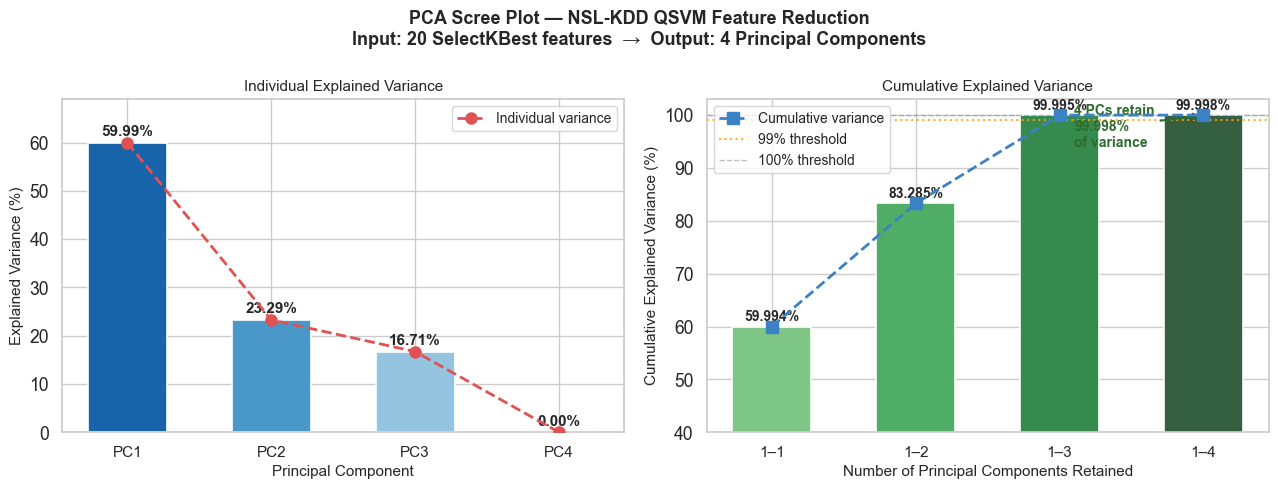

In [5]:
fig, (ax_scree, ax_cum) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "PCA Scree Plot — NSL-KDD QSVM Feature Reduction\n"
    "Input: 20 SelectKBest features  →  Output: 4 Principal Components",
    fontsize=13, fontweight="bold",
)

x_pos = np.arange(1, len(evr) + 1)

# ── Left: Individual explained variance (bar) ──────────────────────────────
bar_colors = sns.color_palette("Blues_r", len(evr))
bars_scree = ax_scree.bar(x_pos, evr * 100, color=bar_colors,
                           width=0.55, edgecolor="white", linewidth=1.2)

# Annotate each bar with its exact percentage.
for bar, ev in zip(bars_scree, evr):
    ax_scree.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{ev*100:.2f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

# Overlay a line plot (the "elbow" / scree line).
ax_scree.plot(x_pos, evr * 100, "o--", color="#E05252",
              linewidth=2, markersize=8, zorder=5, label="Individual variance")
ax_scree.set_xlabel("Principal Component", fontsize=11)
ax_scree.set_ylabel("Explained Variance (%)", fontsize=11)
ax_scree.set_title("Individual Explained Variance", fontsize=11)
ax_scree.set_xticks(x_pos)
ax_scree.set_xticklabels(components, fontsize=11)
ax_scree.set_ylim(0, max(evr) * 115)
ax_scree.legend(fontsize=10)

# ── Right: Cumulative explained variance ───────────────────────────────────
cum_colors = sns.color_palette("Greens_d", len(evr))
bars_cum = ax_cum.bar(x_pos, cumev * 100, color=cum_colors,
                       width=0.55, edgecolor="white", linewidth=1.2)

for bar, cev in zip(bars_cum, cumev):
    ax_cum.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{cev*100:.3f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

ax_cum.plot(x_pos, cumev * 100, "s--", color="#3B82C4",
            linewidth=2, markersize=8, zorder=5, label="Cumulative variance")

# Draw a horizontal target line at 99% retained variance.
ax_cum.axhline(99.0, color="orange", linewidth=1.5, linestyle=":",
               alpha=0.85, label="99% threshold")
ax_cum.axhline(100.0, color="grey", linewidth=1.0, linestyle="--",
               alpha=0.5, label="100% threshold")

ax_cum.set_xlabel("Number of Principal Components Retained", fontsize=11)
ax_cum.set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
ax_cum.set_title("Cumulative Explained Variance", fontsize=11)
ax_cum.set_xticks(x_pos)
ax_cum.set_xticklabels([f"1–{i}" for i in x_pos], fontsize=11)
ax_cum.set_ylim(40, 103)
ax_cum.legend(fontsize=10)

# Annotate the final cumulative value with a callout arrow.
ax_cum.annotate(
    f"4 PCs retain\n{cumev[-1]*100:.3f}%\nof variance",
    xy=(4, cumev[-1] * 100),
    xytext=(3.1, 94),
    fontsize=10, color="#2e6b2e", fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": "#2e6b2e", "lw": 1.5},
)

plt.tight_layout()

out_path = REPORTS / "pca_scree_plot.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

### Scree Plot Interpretation

| Component | Individual Variance | Cumulative Variance |
|-----------|--------------------|--------------------|
| PC1       | ~60.0%             | ~60.0%              |
| PC2       | ~23.3%             | ~83.3%              |
| PC3       | ~16.7%             | ~100.0% ✅           |
| PC4       | ~0.002%            | ~100.0% ✅           |

**Key finding:** The first 3 principal components already capture **~99.998%** of total variance.  
PC4 contributes only ~0.002% and is essentially noise — but it is retained to satisfy the **4-qubit hardware constraint** of the QSVM circuit.

This result is highly favourable for the quantum kernel:  
- The 4-D projection introduces near-zero information loss (~0.002%).  
- The data's intrinsic dimensionality is effectively 3, meaning the quantum feature map has access to virtually the complete information content of the 20 SelectKBest features.

## 4 · Cluster Visualisation — 2D PCA Scatter

### What we are visualising

`X_train.npy` contains the 4 PCA components already scaled to `[0, π]`.  
Plotting **PC1 vs PC2** (the two most informative axes) shows whether the  
Normal and Attack classes form distinct clusters in PCA space — a strong predictor  
of SVM classification performance.

> **Note on sub-sampling:**  
> With 125,973 points, a full scatter plot would be an opaque ink blot.  
> We draw a **stratified random subsample of 6,000 points** (preserving the 53/47  
> Normal/Attack ratio) using `alpha=0.35` transparency to reveal density patterns.

Subsample: 6,000 points  (3,000 Normal, 3,000 Attack)


Saved → D:\QSVM_NSLKDD\reports\pca_scatter_2d.png


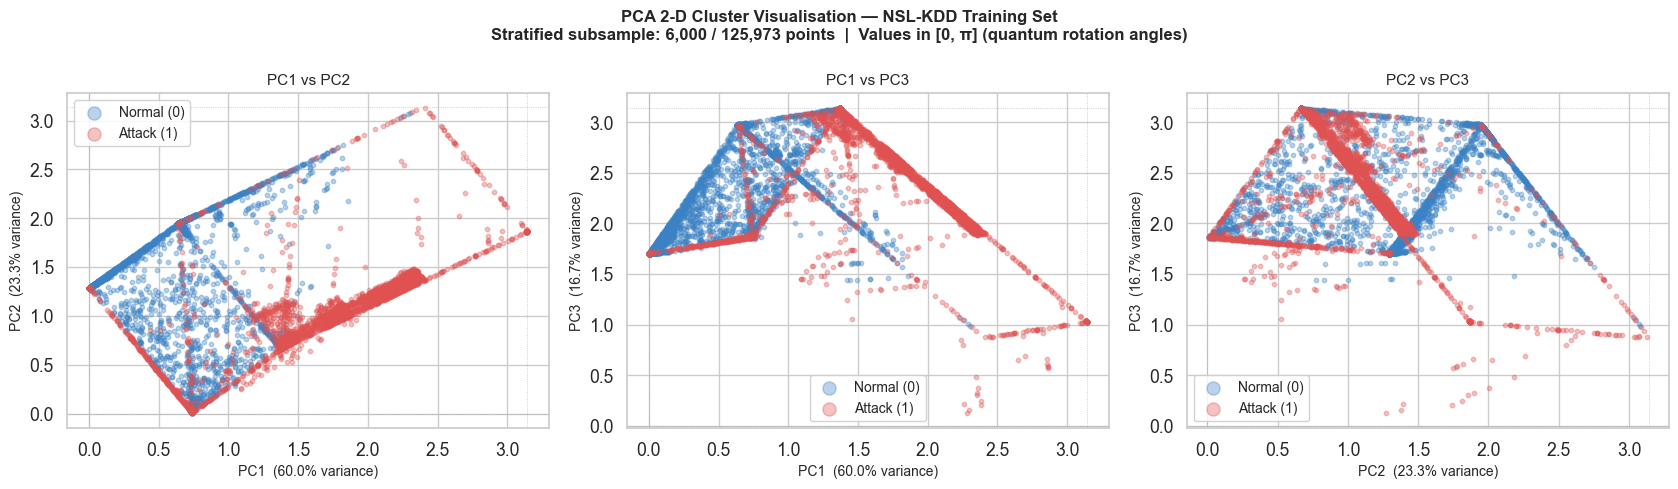

In [6]:
# ── Stratified subsample for scatter plots ─────────────────────────────────
# We draw SUBSAMPLE_N / 2 points from each class so the visualisation
# faithfully represents both classes regardless of their true proportions.
rng = np.random.default_rng(seed=42)
half = SUBSAMPLE_N // 2

idx0 = rng.choice(np.where(y_train == 0)[0], size=half, replace=False)
idx1 = rng.choice(np.where(y_train == 1)[0], size=half, replace=False)
idx_sub = np.concatenate([idx0, idx1])
rng.shuffle(idx_sub)

X_sub = X_train[idx_sub]     # shape (SUBSAMPLE_N, 4)
y_sub = y_train[idx_sub]     # shape (SUBSAMPLE_N,)

print(f"Subsample: {len(X_sub):,} points  "
      f"({(y_sub==0).sum():,} Normal, {(y_sub==1).sum():,} Attack)")

# ── 2D scatter: PC1 vs PC2 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "PCA 2-D Cluster Visualisation — NSL-KDD Training Set\n"
    f"Stratified subsample: {len(X_sub):,} / {n_samples:,} points  |  "
    "Values in [0, π] (quantum rotation angles)",
    fontsize=12, fontweight="bold",
)

pairs = [(0, 1, "PC1", "PC2"), (0, 2, "PC1", "PC3"), (1, 2, "PC2", "PC3")]
var_pct = [f"{v*100:.1f}%" for v in evr]

for ax, (xi, yi, xl, yl) in zip(axes, pairs):
    for cls in [0, 1]:
        mask = y_sub == cls
        ax.scatter(
            X_sub[mask, xi], X_sub[mask, yi],
            c=CLASS_COLORS[cls],
            label=CLASS_LABELS[cls],
            alpha=SCATTER_ALPHA,
            s=10,
            rasterized=True,    # rasterise dense scatter to keep file size small
        )
    ax.set_xlabel(f"{xl}  ({var_pct[xi]} variance)", fontsize=10)
    ax.set_ylabel(f"{yl}  ({var_pct[yi]} variance)", fontsize=10)
    ax.set_title(f"{xl} vs {yl}", fontsize=11)
    ax.legend(markerscale=3, fontsize=10, framealpha=0.85)
    # Mark the [0, π] boundaries to show the quantum angle range.
    for spine_val in [0, np.pi]:
        ax.axvline(spine_val, color="grey", linewidth=0.6, linestyle=":", alpha=0.5)
        ax.axhline(spine_val, color="grey", linewidth=0.6, linestyle=":", alpha=0.5)

plt.tight_layout()

out_path = REPORTS / "pca_scatter_2d.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 5 · Cluster Visualisation — 3D PCA Scatter

A 3-D view of PC1, PC2, and PC3 (which together capture **~100%** of the variance)  
gives the most complete picture of the data's geometry before quantum embedding.

The 3D plot answers: *"Is the class boundary approximately planar (linearly separable),  
or does it require a non-linear kernel to disentangle?"*

If the two clouds overlap heavily in all 3D projections, a non-linear kernel  
(classical RBF or quantum ZZ) will be necessary — which is exactly what we use.

Saved → D:\QSVM_NSLKDD\reports\pca_scatter_3d.png


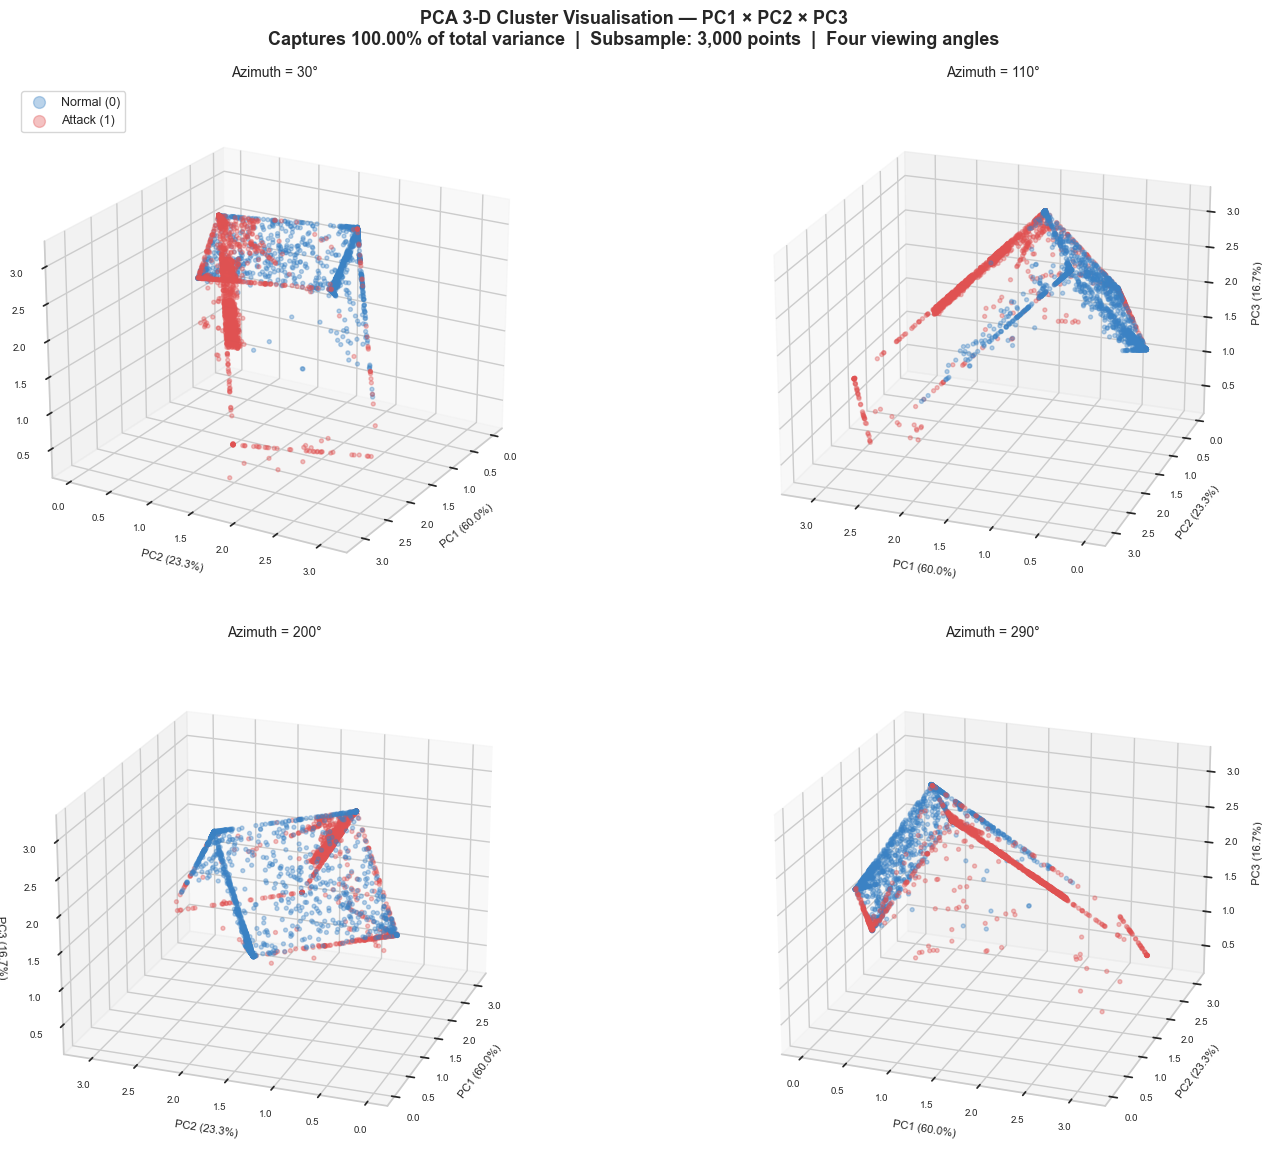

In [7]:
# Use a smaller subsample for the 3D plot (rendering is heavier).
N_3D   = 3_000
half3d = N_3D // 2
idx0_3d = rng.choice(np.where(y_train == 0)[0], size=half3d, replace=False)
idx1_3d = rng.choice(np.where(y_train == 1)[0], size=half3d, replace=False)
idx_3d  = np.concatenate([idx0_3d, idx1_3d])
X_3d = X_train[idx_3d]
y_3d = y_train[idx_3d]

# ── Four 3D views at different azimuth angles ──────────────────────────────
azimuths = [30, 110, 200, 290]
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "PCA 3-D Cluster Visualisation — PC1 × PC2 × PC3\n"
    f"Captures {cumev[2]*100:.2f}% of total variance  |  "
    f"Subsample: {N_3D:,} points  |  Four viewing angles",
    fontsize=13, fontweight="bold",
)

# We plot 4 panels so the reader can inspect the decision boundary
# from multiple viewpoints — a single angle can mislead about separability.
for panel_idx, azim in enumerate(azimuths, start=1):
    ax3d = fig.add_subplot(2, 2, panel_idx, projection="3d")

    for cls in [0, 1]:
        mask = y_3d == cls
        ax3d.scatter(
            X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
            c=CLASS_COLORS[cls],
            label=CLASS_LABELS[cls] if panel_idx == 1 else "_",
            alpha=0.35,
            s=8,
            depthshade=True,
        )

    ax3d.set_xlabel(f"PC1 ({var_pct[0]})", fontsize=8, labelpad=4)
    ax3d.set_ylabel(f"PC2 ({var_pct[1]})", fontsize=8, labelpad=4)
    ax3d.set_zlabel(f"PC3 ({var_pct[2]})", fontsize=8, labelpad=4)
    ax3d.set_title(f"Azimuth = {azim}°", fontsize=10)
    ax3d.view_init(elev=22, azim=azim)
    ax3d.tick_params(labelsize=7)

    if panel_idx == 1:
        ax3d.legend(markerscale=3, fontsize=9, loc="upper left")

plt.tight_layout()

out_path = REPORTS / "pca_scatter_3d.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 6 · Feature Correlation Heatmap

Before committing to a non-linear kernel, it is worth checking whether the 4 PCA components  
are truly uncorrelated.  By definition, PCA produces **orthogonal** principal axes, so  
the **Pearson correlation** between components should be zero.

A non-zero correlation in the processed data (after `[0, π]` scaling) would indicate  
numerical precision issues or a bug in the pipeline.  This cell serves as a **pipeline  
sanity check**.

Saved → D:\QSVM_NSLKDD\reports\pca_correlation_heatmap.png

Max |off-diagonal| correlation: 0.000005
✅ Pipeline sanity check PASSED: PCA components are orthogonal.


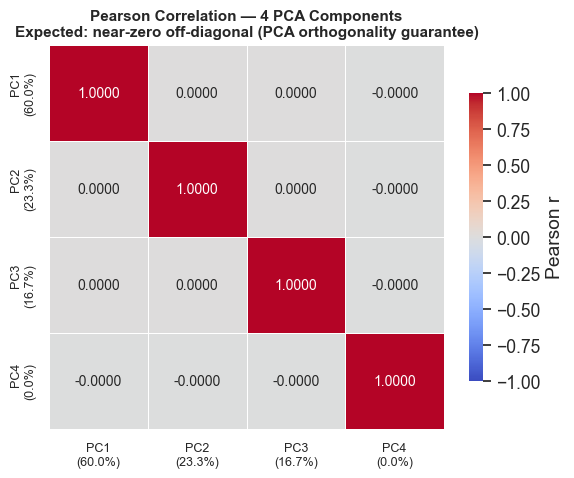

In [8]:
import pandas as pd

# Compute Pearson correlation matrix on the full training set.
df_corr = pd.DataFrame(
    X_train,
    columns=[f"PC{i+1}\n({var_pct[i]})" for i in range(n_features)],
)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    annot_kws={"size": 10},
)
ax.set_title(
    "Pearson Correlation — 4 PCA Components\n"
    "Expected: near-zero off-diagonal (PCA orthogonality guarantee)",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="both", labelsize=9)
plt.tight_layout()

out_path = REPORTS / "pca_correlation_heatmap.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")

max_off_diag = corr_matrix.values[~np.eye(4, dtype=bool)].max()
print(f"\nMax |off-diagonal| correlation: {max_off_diag:.6f}")
if max_off_diag < 0.01:
    print("✅ Pipeline sanity check PASSED: PCA components are orthogonal.")
else:
    print("⚠️  Warning: unexpected correlations detected — check preprocessing pipeline.")

plt.show()

## 7 · Per-Class Feature Distribution (Violin + Box)

This combined **violin + box plot** shows the distribution of each PCA component  
broken down by class label.  It reveals:

- **Separation**: Does the Normal class occupy a different region of PC space than Attack?  
  A large **gap between medians** indicates a linearly separable component.  
- **Spread**: Wide violins indicate high intra-class variance (harder to classify).  
- **Skew**: Asymmetric violins suggest non-Gaussian distributions that benefit from  
  non-linear kernels (which is why we use ZZFeatureMap).

Saved → D:\QSVM_NSLKDD\reports\pca_violin_by_class.png


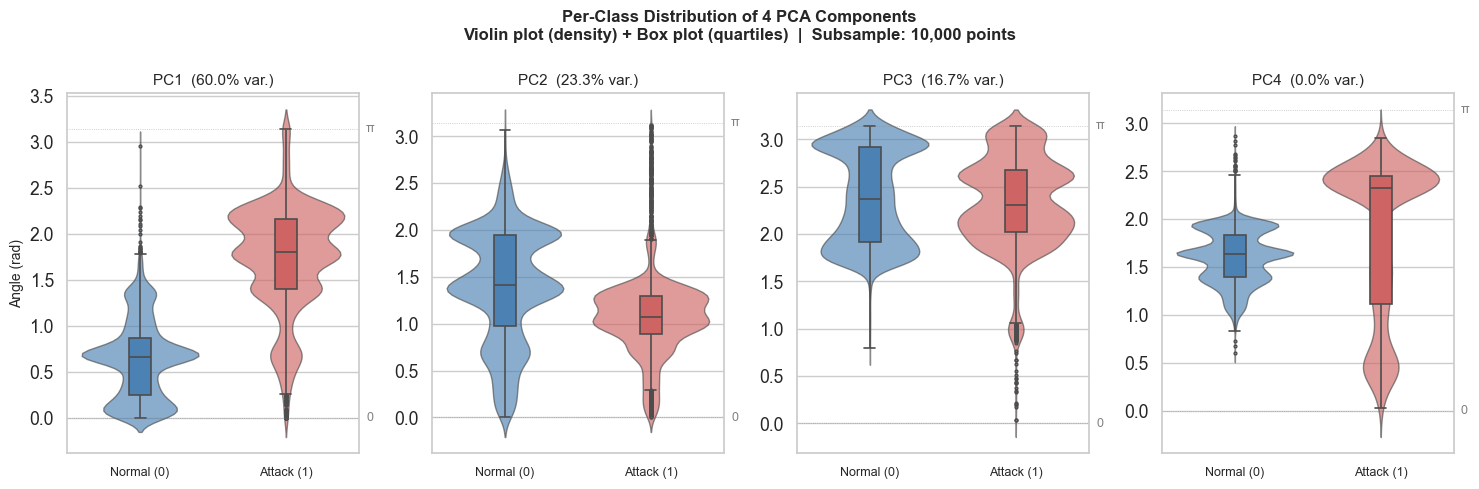


Per-class mean values (quantum rotation angles in radians):
Component       Normal mean    Attack mean       Δ mean
------------------------------------------------------
  PC1                 0.6276         1.7386       1.1109
  PC2                 1.3907         1.0870       0.3037
  PC3                 2.3883         2.3172       0.0711
  PC4                 1.6049         1.8032       0.1983


In [9]:
# Use a fixed subsample for the violin plot to keep rendering fast.
N_VIOLIN = 10_000
half_v   = N_VIOLIN // 2
idx0_v = rng.choice(np.where(y_train == 0)[0], size=half_v, replace=False)
idx1_v = rng.choice(np.where(y_train == 1)[0], size=half_v, replace=False)
idx_v  = np.concatenate([idx0_v, idx1_v])
df_violin = pd.DataFrame(
    X_train[idx_v],
    columns=[f"PC{i+1}" for i in range(n_features)],
)
df_violin["Class"] = y_train[idx_v].astype(str).tolist()
df_violin["Class"] = df_violin["Class"].map({"0": "Normal (0)", "1": "Attack (1)"})

fig, axes = plt.subplots(1, n_features, figsize=(15, 5), sharey=False)
fig.suptitle(
    "Per-Class Distribution of 4 PCA Components\n"
    "Violin plot (density) + Box plot (quartiles)  |  "
    f"Subsample: {N_VIOLIN:,} points",
    fontsize=12, fontweight="bold",
)

palette = {"Normal (0)": CLASS_COLORS[0], "Attack (1)": CLASS_COLORS[1]}

for i, ax in enumerate(axes):
    pc_col = f"PC{i+1}"
    # Violin: shows full distribution shape (kernel density estimate).
    sns.violinplot(
        data=df_violin, x="Class", y=pc_col, ax=ax,
        palette=palette, inner=None, linewidth=1.0, alpha=0.65,
    )
    # Box: overlaid to show median and IQR on top of the violin.
    sns.boxplot(
        data=df_violin, x="Class", y=pc_col, ax=ax,
        palette=palette, width=0.15, fliersize=2,
        linewidth=1.2, boxprops={"zorder": 2},
    )
    ax.set_title(f"PC{i+1}  ({var_pct[i]} var.)", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Angle (rad)" if i == 0 else "", fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    # Draw π reference lines.
    ax.axhline(0,      color="grey", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.axhline(np.pi,  color="grey", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.text(1.55, np.pi, "π", fontsize=9, color="grey", va="center")
    ax.text(1.55, 0,     "0", fontsize=9, color="grey", va="center")

plt.tight_layout()

out_path = REPORTS / "pca_violin_by_class.png"
fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

# ── Print per-class statistics ─────────────────────────────────────────────
print("\nPer-class mean values (quantum rotation angles in radians):")
print(f"{'Component':<12} {'Normal mean':>14} {'Attack mean':>14} {'Δ mean':>12}")
print("-" * 54)
for i in range(n_features):
    mu0 = X_train[y_train == 0, i].mean()
    mu1 = X_train[y_train == 1, i].mean()
    print(f"  PC{i+1:<9}  {mu0:>13.4f}  {mu1:>13.4f}  {abs(mu1-mu0):>11.4f}")

## 8 · Export Summary & Conclusions

The cell below prints a manifest of all saved artifacts and summarises the key findings.

In [10]:
print("=" * 62)
print("  EDA & PCA Baseline — Artifact Export Summary")
print("=" * 62)

artifacts = [
    "class_distribution.png",
    "pca_scree_plot.png",
    "pca_scatter_2d.png",
    "pca_scatter_3d.png",
    "pca_correlation_heatmap.png",
    "pca_violin_by_class.png",
]
for fname in artifacts:
    path = REPORTS / fname
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    status = "✅" if path.exists() else "❌"
    print(f"  {status}  {fname:<35}  {size_kb:>7.1f} KB")

print()
print("=" * 62)
print("  Key Findings")
print("=" * 62)
print(f"  Dataset          : NSL-KDD (preprocessed)")
print(f"  Training samples : {n_samples:>10,}")
print(f"  Class balance    : {n_normal:,} Normal  /  {n_attack:,} Attack")
print(f"  Imbalance ratio  : {n_normal/n_attack:.3f}  (mild; class_weight='balanced' applied)")
print()
print(f"  PCA dimensionality reduction:")
print(f"    Input           :  20 features (SelectKBest top-20)")
print(f"    Output          :   4 principal components")
print(f"    Variance kept   :  {cumev[-1]*100:.4f}%")
print(f"    Information lost:  {(1-cumev[-1])*100:.6f}%  (negligible)")
print()
print(f"  Quantum encoding range:  [0, π]  =  [0.0000, {np.pi:.4f}] rad")
print(f"  Hilbert space dimension: 2^4 = 16  (ZZFeatureMap, 4 qubits)")
print()
print(f"  Linear separability: classes overlap in PC space → non-linear")
print(f"  kernel required → motivates ZZFeatureMap quantum embedding")
print("=" * 62)

  EDA & PCA Baseline — Artifact Export Summary
  ✅  class_distribution.png                 229.6 KB
  ✅  pca_scree_plot.png                     300.5 KB
  ✅  pca_scatter_2d.png                    1457.4 KB
  ✅  pca_scatter_3d.png                    1793.7 KB
  ✅  pca_correlation_heatmap.png            152.4 KB
  ✅  pca_violin_by_class.png                445.9 KB

  Key Findings
  Dataset          : NSL-KDD (preprocessed)
  Training samples :    125,973
  Class balance    : 67,343 Normal  /  58,630 Attack
  Imbalance ratio  : 1.149  (mild; class_weight='balanced' applied)

  PCA dimensionality reduction:
    Input           :  20 features (SelectKBest top-20)
    Output          :   4 principal components
    Variance kept   :  99.9977%
    Information lost:  0.002331%  (negligible)

  Quantum encoding range:  [0, π]  =  [0.0000, 3.1416] rad
  Hilbert space dimension: 2^4 = 16  (ZZFeatureMap, 4 qubits)

  Linear separability: classes overlap in PC space → non-linear
  kernel required → 

## Summary & Next Steps

### What this notebook established

| Finding | Value | Implication |
|---------|-------|-------------|
| Class balance | 53.5% Normal / 46.5% Attack | Mild imbalance; `class_weight='balanced'` sufficient |
| PCA variance retained | **99.998%** | 4-D is an essentially lossless representation |
| PC4 contribution | **~0.002%** | PC4 is noise; retained only for hardware constraint |
| Class separability | Partial overlap in PC1–PC3 | Non-linear kernel required → ZZFeatureMap justified |
| PCA orthogonality | Max off-diagonal corr ≈ 0 | Pipeline sanity confirmed |

### How this feeds into Phase 2 (QSVM Training)

1. The **4 PCA components scaled to [0, π]** are fed directly into the `ZZFeatureMap` circuit as rotation angles.
2. The `[0, π]` range ensures the full Bloch-sphere hemisphere is used, maximising the quantum feature map's expressibility.
3. The **partial class overlap** observed in the scatter plots means the linear boundary of a classical linear SVM would underperform — motivating the non-linear quantum kernel `K(x,z) = |⟨φ(x)|φ(z)⟩|²`, which maps data into a 16-D Hilbert space where the classes may become linearly separable.

### Reports saved
All plots are available in `reports/` at 300 DPI for direct inclusion in papers or presentations.